In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
from tqdm import tqdm

from src.mps_utils import to_comp_basis

## Helper functions

In [8]:
def get_all_failed_runs():
    qpd6_result_folders = []
    for folder in os.listdir("data"):
        if folder.startswith("qpd6_new_solver_test"):
            qpd6_result_folders.append(folder)

    all_failed_runs = []
    for folder in qpd6_result_folders:
        for subdir in os.listdir(os.path.join("data", folder)):
            for gradient_method in ["ols_noridge", "ols_ridge0.01"]:
                try:
                    failed_runs = os.listdir(os.path.join("data", folder, subdir, gradient_method, 'failed_runs'))
                    all_failed_runs.extend(
                        [os.path.join("data", folder, subdir, gradient_method, 'failed_runs', fn) for fn in failed_runs]
                    )
                except FileNotFoundError:
                    print(f"No failed runs found for {folder} {subdir} {gradient_method}")
                    pass
    return all_failed_runs

all_failed_runs = get_all_failed_runs()


No failed runs found for qpd6_new_solver_test chi_16 ols_noridge
No failed runs found for qpd6_new_solver_test chi_16 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_4 ols_noridge
No failed runs found for qpd6_new_solver_test chi_4 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_8 ols_noridge
No failed runs found for qpd6_new_solver_test chi_8 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_2 ols_noridge
No failed runs found for qpd6_new_solver_test chi_2 ols_ridge0.01
No failed runs found for qpd6_new_solver_test chi_6 ols_noridge
No failed runs found for qpd6_new_solver_test chi_6 ols_ridge0.01


In [ ]:
success_count = 0
all_failed_results = []
for failed_result_path in tqdm(all_failed_runs):
    failed_result = pickle.load(open(failed_result_path, "rb"))
    all_failed_results.append(failed_result)

import datetime 
pickle.dump(all_failed_results, open(f"data/debug/all_failed_results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl", "wb"))


100%|██████████| 333/333 [00:01<00:00, 180.74it/s]


## Analysis

In [30]:
all_failed_results = pickle.load(open("data/debug/all_failed_results_20260112_145740.pkl", "rb"))


{'uuid': '3583a8d9-f799-42b3-a7f4-3144ad772352',
 'timestamp': '20260108_170803',
 'chi': 1,
 'num_players': 6,
 'max_num_steps': 1000,
 'eps': 0.02,
 'num_perturbations': 20,
 'subroutine_max_iter': 1000,
 'subroutine_lr': 0.03,
 'max_subroutine_lr': 0.6,
 'perturbation_method': 'unitary',
 'seed': 4020020}

In [42]:
state = to_comp_basis(all_failed_results[10]['current_state'])
init_state = all_failed_results[10]['problematic_result']['state'][-1].reshape(2**6)

In [43]:
init_state - state

array([ 1.03604386e-05, -1.32632978e-05, -1.17284288e-05,  6.60074035e-06,
       -1.55973113e-05,  1.21384377e-05, -1.67459913e-05,  7.91177933e-06,
       -7.67529799e-06, -5.19630435e-06,  1.07843219e-05,  1.01014266e-05,
        5.62986848e-06, -1.38967442e-06,  1.31935513e-05, -2.49817326e-06,
       -7.12311211e-07,  2.93585745e-06,  1.70674305e-05,  4.76471861e-06,
        1.10829961e-05,  1.77371409e-05,  1.58268989e-05,  2.22447963e-05,
        2.60154671e-05, -1.38238577e-06,  8.60916983e-06,  6.64280046e-06,
        2.08820258e-05,  3.62299006e-05, -2.42393720e-05, -2.94462073e-05,
       -1.52861401e-05,  3.96212596e-05, -2.76411195e-05,  6.70247426e-06,
        1.82201293e-05,  1.69037907e-05, -1.46256886e-07, -7.74229536e-06,
       -7.84785232e-06,  4.45186728e-06,  8.57263288e-06, -1.22228737e-05,
        1.05191417e-05, -1.06168910e-06, -1.23022550e-05, -7.81427792e-06,
        1.29894630e-06, -1.21315391e-07, -8.37218227e-06, -8.79360691e-06,
       -6.45425950e-06,  

In [29]:
states[-1].reshape(2**6)
from src.solver import find_nash_eq1
from src.game import get_default_cyclic_players
from copy import deepcopy

result = failed_run_results[1]
states = result['problematic_result']['state']
states_mps = result['problematic_result']['state_']
a = deepcopy(states_mps[0])

H = get_default_cyclic_players(6)

result = find_nash_eq1(
    a,
    H,
    max_iter=1000,
    alpha=0.4,
    convergence_threshold=1e-7,
    expl_threshold=1e-7,
    use_tqdm=True,
    expl_check_interval=50,
    return_history=True,
    real_strategies=True,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

 20%|██        | 200/1000 [00:00<00:03, 251.09it/s]


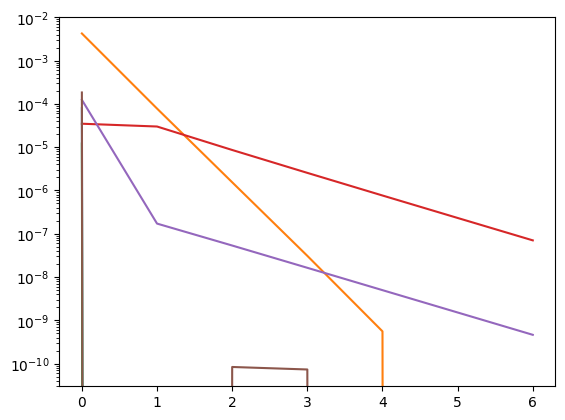

In [28]:
plt.plot(result['expl'])
plt.yscale('log')